<a id='1'></a>
## 1. Setup & Load Data
- Import pandas, numpy, matplotlib, seaborn
- Load FoodDelivery.csv into a DataFrame

In [47]:
%load_ext autoreload
%autoreload 2

%pip install scikit-learn


from pathlib import Path
import sys
project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.cleaning import readData


diabetes_df = readData()

display(diabetes_df)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Note: you may need to restart the kernel to use updated packages.


,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0,6,148,72,35,0,33.6,0.627,50
1,1,1,85,66,29,0,26.6,0.351,31
2,2,8,183,64,0,0,23.3,0.672,32
3,3,1,89,66,23,94,28.1,0.167,21
4,4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...,...
763,763,10,101,76,48,180,32.9,0.171,63
764,764,2,122,70,27,0,36.8,0.340,27
765,765,5,121,72,23,112,26.2,0.245,30
766,766,1,126,60,0,0,30.1,0.349,47


<a id='2'></a>
## 2. Structural Overview
- df.shape
- df.columns and df.dtypes
- df.head() / df.tail()
- df.info()

In [48]:

print(f"{diabetes_df.shape[0]} rows x {diabetes_df.shape[1]} columns" )

print('\n======= Types =======\n')
dtypes_df = pd.DataFrame(diabetes_df.dtypes, columns=['Data Type'])
display(dtypes_df)

print('\n======= Head =======\n')
display(diabetes_df.head())
print('\n======= Tail =======\n')
display(diabetes_df.tail())

print('\n======= Random Sample =======\n')
sample = diabetes_df.sample(n=20)
display(sample)


768 rows x 9 columns

======= Types =======



,Data Type
Unnamed: 0,int64
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64



======= Head =======



,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0,6,148,72,35,0,33.6,0.627,50
1,1,1,85,66,29,0,26.6,0.351,31
2,2,8,183,64,0,0,23.3,0.672,32
3,3,1,89,66,23,94,28.1,0.167,21
4,4,0,137,40,35,168,43.1,2.288,33



======= Tail =======



,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
763,763,10,101,76,48,180,32.9,0.171,63
764,764,2,122,70,27,0,36.8,0.340,27
765,765,5,121,72,23,112,26.2,0.245,30
766,766,1,126,60,0,0,30.1,0.349,47
767,767,1,93,70,31,0,30.4,0.315,23



======= Random Sample =======



,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
312,312,2,155,74,17,96,26.6,0.433,27
556,556,1,97,70,40,0,38.1,0.218,30
677,677,0,93,60,0,0,35.3,0.263,25
446,446,1,100,72,12,70,25.3,0.658,28
517,517,7,125,86,0,0,37.6,0.304,51
752,752,3,108,62,24,0,26.0,0.223,25
208,208,1,96,64,27,87,33.2,0.289,21
425,425,4,184,78,39,277,37.0,0.264,31
552,552,6,114,88,0,0,27.8,0.247,66
540,540,8,100,74,40,215,39.4,0.661,43


<a id='3'></a>
## 3. Missing Values Analysis
- df.isna().sum()
- Percentage missing per column
- Missingness heatmap: sns.heatmap(df.isna(), cbar=False)

In [49]:

print('======= missing values count  ========')
print(diabetes_df.isna().sum())

print('\n\n======= missing values percentages ========')
print((diabetes_df.isna().mean()*100).round(2))

======= missing values count  ========
Unnamed: 0                  0
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


======= missing values percentages ========
Unnamed: 0                  0.0
Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
dtype: float64


<a id='4'></a>
## 4. Duplicate Check
- df.duplicated().sum()
- df['Order_ID'].duplicated().sum()

In [50]:
diabetes_df = diabetes_df.rename(columns={'Unnamed: 0' : 'ID'})
print(f"duplicated ids count: {diabetes_df['ID'].duplicated().sum()}\n")
print(f"duplicates: {diabetes_df.duplicated().sum()}\n")
diabetes_df = diabetes_df.drop(columns='ID')

duplicated ids count: 0

duplicates: 0



<a id='5'></a>
## 5. Distribution Analysis
- `df.describe()`
- Histograms
- Boxplots
- Skewness analysis using `df.skew()`

In [57]:
display(diabetes_df.describe())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


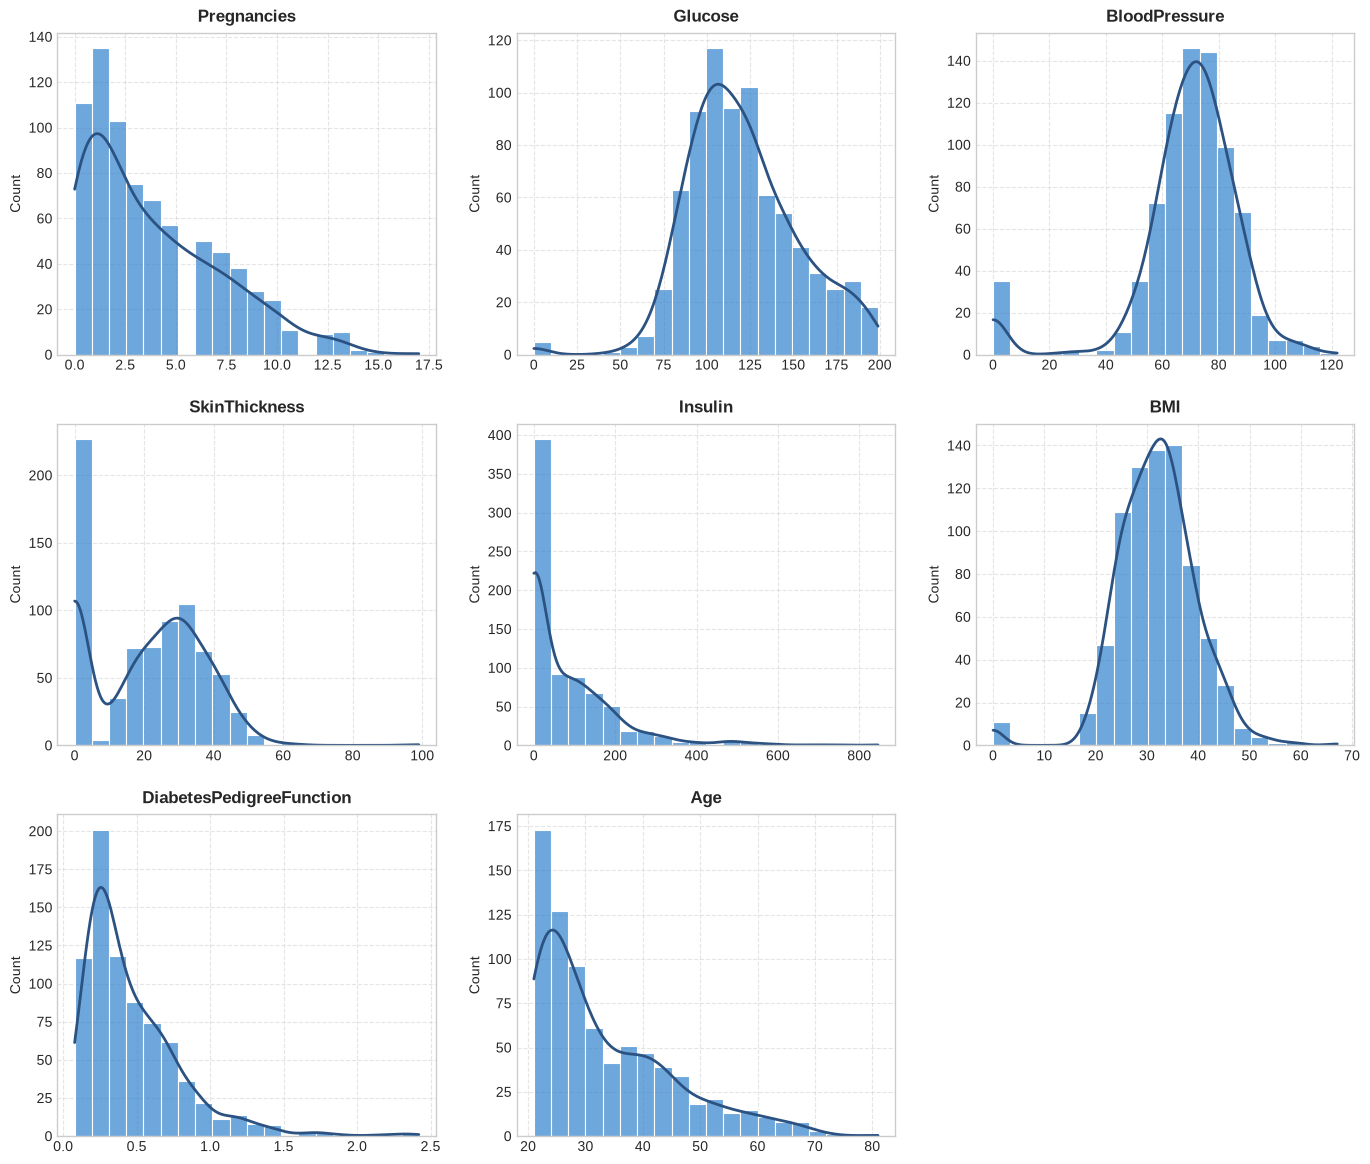

In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

columns = diabetes_df.columns
ncols = 3
nrows = math.ceil(len(columns) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(columns):
  ax = axes[i]

  sns.histplot(
      diabetes_df[col].dropna(),
      bins=20,
      color="#3182ce", 
      edgecolor="#ffffff",
      linewidth=0.8,
      alpha=0.7,  
      kde=True,
      ax=ax,
  )

  if ax.lines:
    ax.lines[0].set_color("#2c5282") 
    ax.lines[0].set_linewidth(2)

  ax.set_title(col, fontsize=12, fontweight="bold", pad=8)
  ax.tick_params(labelsize=10)
  ax.grid(True, linestyle="--", alpha=0.5)
  ax.set_xlabel("") 

for j in range(len(columns), len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout(pad=2.0)
plt.show()

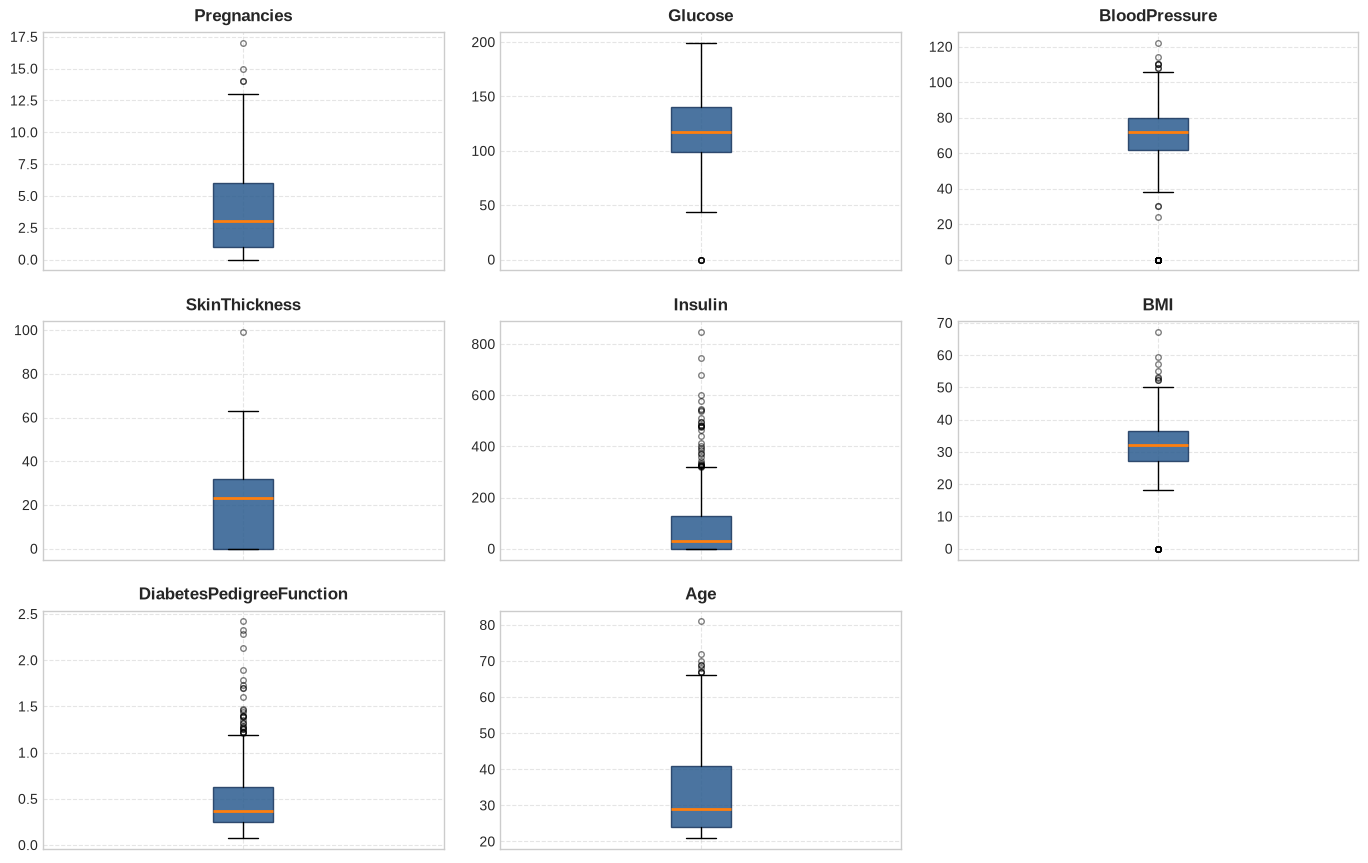

In [68]:

fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(14, 3 * nrows))
axes = axes.flatten()

for i, col in enumerate(columns):
  ax = axes[i]

  ax.boxplot(
      diabetes_df[col].dropna(),
      orientation="vertical",
      patch_artist=True,  
      boxprops=dict(facecolor="#2b5c8f", color="#1a365d", alpha=0.85),
      medianprops=dict(color="#ff7f0e", linewidth=2),  
      flierprops=dict(
          marker="o", color="#d62728", alpha=0.5, markersize=4
      ),
  )

  ax.set_title(col, fontsize=12, fontweight="bold", pad=8)
  ax.tick_params(
      axis="x", which="both", bottom=False, top=False, labelbottom=False
  )
  ax.tick_params(labelsize=10)
  ax.grid(True, linestyle="--", alpha=0.5)

# Hide any leftover empty subplots
for j in range(len(columns), len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout(pad=2.0)
plt.show()

In [76]:
diabetes_df.skew()

Pregnancies                 0.901674
Glucose                     0.173754
BloodPressure              -1.843608
SkinThickness               0.109372
Insulin                     2.272251
BMI                        -0.428982
DiabetesPedigreeFunction    1.919911
Age                         1.129597
dtype: float64